# 04 — KNN Recommendation (Simon)
Two KNN approaches:
1. **Content-based**: cosine similarity on song feature profiles.
2. **Collaborative filtering**: cosine similarity on user demographic vectors.

Both are evaluated with leave-one-out cross-validation, then compared to K-means.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import load_and_clean, build_song_features, build_user_features, build_joint_features
from content_knn import ContentKNN
from collab_knn import CollabKNN
from kmeans_recommender import KMeansRecommender, elbow_analysis
from sklearn.preprocessing import StandardScaler
from evaluate import leave_one_out_eval, kmeans_genre_accuracy, print_comparison

sns.set_theme(style='whitegrid')
df = load_and_clean()
sf = build_song_features(df)
uf = build_user_features(df)
jf = build_joint_features(df)
print('Rows:', len(df), '| Users:', df['user_id'].nunique())

Rows: 170 | Users: 116


## Part 1: Content-Based KNN

In [2]:
content_model = ContentKNN().fit(df, sf)

sample_user = df['user_id'].value_counts().index[0]
print(f'User: {sample_user}')
print('Submitted songs:')
print(df[df['user_id'] == sample_user][['song', 'genre', 'release_year']].to_string(index=False))
print('\nContent-based top-5 recommendations:')
print(content_model.recommend(sample_user, top_k=5).to_string(index=False))

User: mariokart
Submitted songs:
                song      genre release_year
           TITFORTAT        Pop        2020+
  Birds of a Feather        Pop        2020+
         The Subway         Pop        2020+
   BAILE INoLVIDABLE      Latin        2020+
Rolling in the Deep  R&B / Soul    2010–2019
         Getaway Car       Rock        2020+
   Sign of the Times       Rock    2010–2019
           Hurricane        Pop    2010–2019
            Takedown      K-pop        2020+
        Meant to be     Country    2010–2019

Content-based top-5 recommendations:
                   song            artist genre release_year  similarity
          Fame is a gun       Addison Rae   Pop        2020+     0.99187
So Easy To Fall In Love       Olivia Dean   Pop        2020+     0.99187
                  Taste Sabrina Carpenter   Pop        2020+     0.99187
                 Sue me     Audrey Hobert   Pop        2020+     0.99187
                moshpit       renforshort   Pop        2020+     0.99

## Part 2: Collaborative Filtering KNN

In [3]:
collab_model = CollabKNN(k_neighbors=5).fit(df, uf)

print(f'User: {sample_user}')
print('Collaborative top-5 recommendations:')
print(collab_model.recommend(sample_user, top_k=5).to_string(index=False))

User: mariokart
Collaborative top-5 recommendations:
                      song              artist               genre  neighbor_count
                       APT Rosé and Bruno Mars                 Pop               1
                    Dreams       Fleetwood Mac                 Pop               1
               Love Me Not         Ravyn Lenae                 Pop               1
                Man I Need         Olivia Dean                 Pop               1
Reality TV Argument Bleeds           Wednesday Indie / Alternative               1


## Part 3: Effect of K on collaborative filtering

k_neighbors= 3: genre_match@5=0.6364
k_neighbors= 5: genre_match@5=0.7727
k_neighbors=10: genre_match@5=0.8636
k_neighbors=15: genre_match@5=0.8636
k_neighbors=20: genre_match@5=0.7727


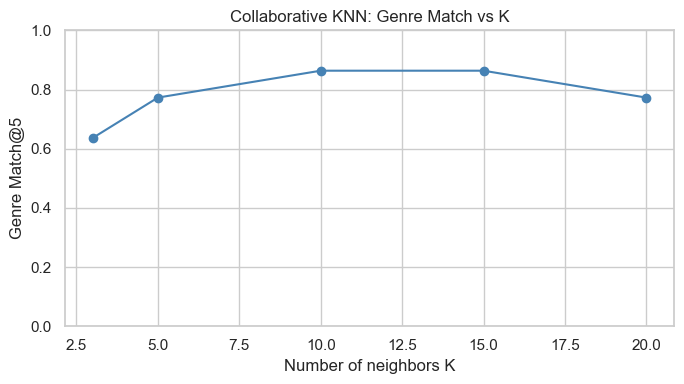

In [4]:
ks = [3, 5, 10, 15, 20]
genre_matches = []
for k in ks:
    m = CollabKNN(k_neighbors=k).fit(df, uf)
    def rec_fn(uid, excl, _m=m, _k=5):
        return _m.recommend(uid, top_k=_k)
    res = leave_one_out_eval(df, rec_fn, top_k=5)
    genre_matches.append(res['genre_match_at_k'])
    print(f'k_neighbors={k:2d}: genre_match@5={res["genre_match_at_k"]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, genre_matches, marker='o', color='steelblue')
ax.set_xlabel('Number of neighbors K')
ax.set_ylabel('Genre Match@5')
ax.set_title('Collaborative KNN: Genre Match vs K')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Part 4: Leave-one-out evaluation — Content vs Collab

In [5]:
TOP_K = 5

def content_rec(uid, excl):
    return content_model.recommend(uid, top_k=TOP_K)

def collab_rec(uid, excl):
    return collab_model.recommend(uid, top_k=TOP_K)

content_results = leave_one_out_eval(df, content_rec, top_k=TOP_K)
collab_results  = leave_one_out_eval(df, collab_rec,  top_k=TOP_K)

print('Content-based results:', content_results)
print('Collaborative results: ', collab_results)

Content-based results: {'hit_rate': 0.0, 'genre_match_at_k': 0.9545, 'precision_at_k': 0.0, 'recall_at_k': 0.0, 'n_users': 22}
Collaborative results:  {'hit_rate': 0.0, 'genre_match_at_k': 0.7727, 'precision_at_k': 0.0, 'recall_at_k': 0.0, 'n_users': 22}


## Part 5: K-means evaluation (for comparison)

In [6]:
scaler = StandardScaler()
scaled = scaler.fit_transform(jf.values)
k_range = range(2, 11)
inertias, sil_scores = elbow_analysis(scaled, k_range=k_range)
best_k = list(k_range)[int(np.argmax(sil_scores))]

km_model = KMeansRecommender(n_clusters=best_k).fit(df, jf)
kmeans_results = kmeans_genre_accuracy(
    df, km_model.recommend, uf, sf, top_k=1
)
print('K-means results:', kmeans_results)

K-means results: {'genre_accuracy': 0.1529, 'n_rows': 170}


## Part 6: Full comparison summary

In [7]:
print_comparison(content_results, collab_results, kmeans_results)

Metric                          Content KNN   Collab KNN K-means
---------------------------------------------------------------
genre_match_at_k (primary)           0.9545       0.7727  0.1529
---------------------------------------------------------------
hit_rate                             0.0000       0.0000     n/a
precision_at_k                       0.0000       0.0000     n/a
recall_at_k                          0.0000       0.0000     n/a
---------------------------------------------------------------
n evaluated                              22           22     170
Note: KNN hit_rate=0 is expected — 170 unique songs across 172 rows;
      almost no held-out song exists in another user's pool.
      Use genre_match_at_k as the primary comparison metric.


## Part 7: Bar chart comparison

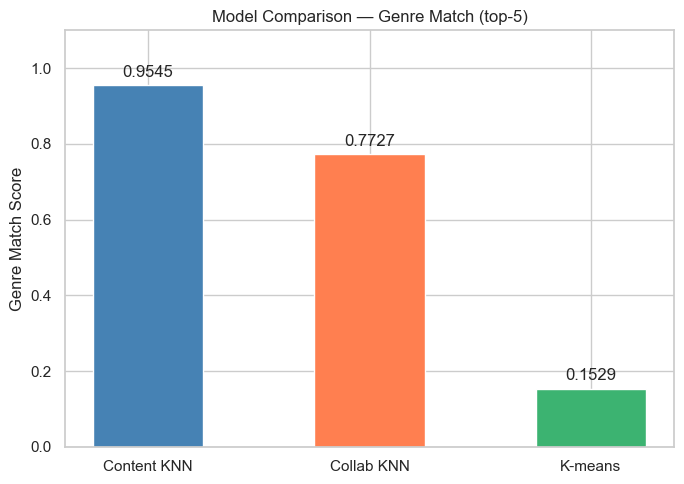

Note: KNN genre_match@K uses leave-one-out (n=22 users with ≥2 songs).
      K-means genre_accuracy is row-level (n=170 rows) — not directly comparable.


In [8]:
models = ['Content KNN', 'Collab KNN', 'K-means']
scores = [
    content_results['genre_match_at_k'],
    collab_results['genre_match_at_k'],
    kmeans_results['genre_accuracy'],
]
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, scores, color=colors, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_ylabel('Genre Match Score')
ax.set_title(f'Model Comparison — Genre Match (top-{TOP_K})')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('Note: KNN genre_match@K uses leave-one-out (n=22 users with ≥2 songs).')
print('      K-means genre_accuracy is row-level (n=170 rows) — not directly comparable.')